In [1]:
using Pkg
using HDF5
#using JSON
using SolidStateDetectors
using Unitful
using Plots
#using LegendHDF5IO
using Measures

In [4]:

filename = "/home/ritaferi/Phd/SSDdev/saved_results_new_function/simulation_with_2_jumps.h5"
min_pot_2  = Float64[]
run_time_2  = Float64[]
grid_dict      = Float64[]

h5open(filename, "r") do f
    for gridname in keys(f)
        g = f[gridname]

        # estrai il numero da "grid_0.5mm" → 0.5
        grid_val = parse(Float64, replace(gridname, "grid_" => "", "mm" => ""))

        push!(run_time_2, read(g["time_s"]))
        push!(min_pot_2,   read(g["min_weighting_potential"]))
        push!(grid_dict, grid_val)
    end
end
using StatsBase  # per `sortperm`, ma puoi anche usare Base

perm = sortperm(grid_dict, rev=true)

grid_dict     = grid_dict[perm]
run_time_2 = run_time_2[perm]
min_pot_2  = min_pot_2[perm]

println("Griglie ordinate decrescente: ", grid_dict)
println("run_time = ", run_time_2)
println("min_pot  = ", min_pot_2)


Griglie ordinate decrescente: [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
run_time = [50.117921328, 44.7187884, 49.526937062, 58.165455611, 65.074084882, 81.911904187, 110.348351454, 155.921428674, 346.160334739, 1342.411458676]
min_pot  = [0.9983182549476624, 0.998266875743866, 0.9970980882644653, 0.998015284538269, 0.997593879699707, 0.9976626634597778, 0.9992419481277466, 0.9970499277114868, 0.9970728754997253, 0.9976280927658081]


In [5]:
wp_old = [
    0.9940752,        # 0.5 mm
    0.9881764,        # 0.45 mm
    0.98422533,       # 0.4 mm
    0.9524081,        # 0.35 mm
    0.90671873,       # 0.3 mm
    0.844832,         # 0.25 mm
    0.5835533,        # 0.2 mm
    0.23646902,       # 0.15 mm
    0.09727309,       # 0.1 mm
    0.009628673,      # 0.05 mm
]
wp_new_grid_ref = min_pot_2
wp_new_coarse_initial_grid_opt = [ 0.9971068, 0.99758047,  0.9987536, 1.0016781,  0.9972573, 0.9972425, 0.99760973,  0.996873, 0.9968678, 0.99365115]
wp_new_coarse_initial_grid = [0.99713,0.99787384 ,0.99935406, 1.0014204, 0.99735886, 0.99727 , 0.99758554, 0.9968726 , 0.9971157,  0.9936677]

grid_comp = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05];



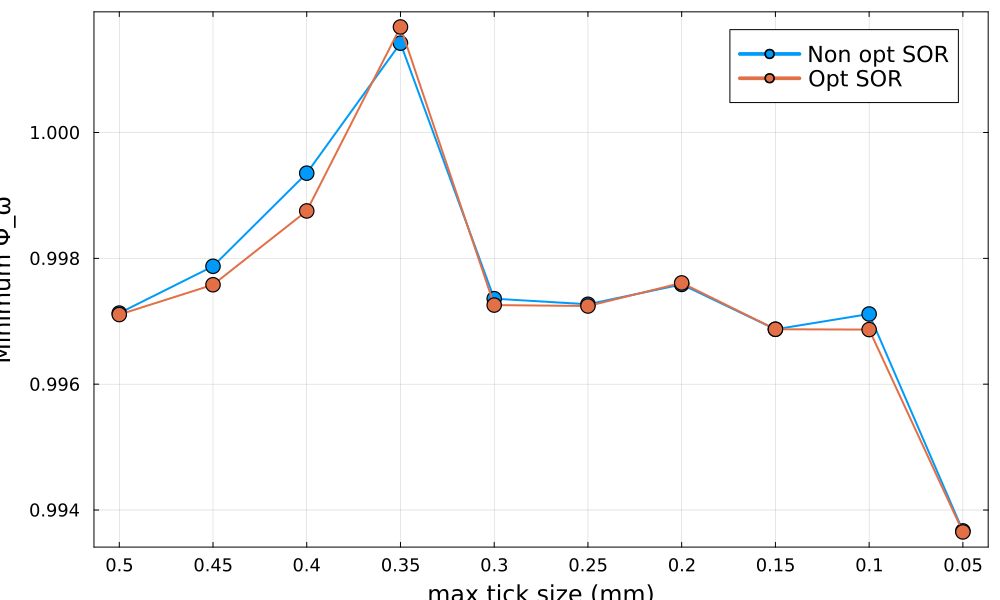

In [9]:
x = 1:length(grid_comp)
labels = string.(grid_comp)

p = plot(
    x, wp_new_coarse_initial_grid;
    seriestype = :path,
    marker = :circle,
    markersize = 8,                 # marker più grandi
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    ylabel = "Minimum Φ_ω",
    lw = 2,                         # linea più spessa
    legend = true,
    label = "Non opt SOR",
    framestyle = :box,
    grid = true,
    gridalpha = 0.1,
    size = (1000, 600),             # figura più grande

    # ---- FONT SIZE ----
    guidefontsize = 16,             # xlabel & ylabel
    tickfontsize = 12,              # numeri assi
    legendfontsize = 15,            # legenda
    titlefontsize = 20              # eventuale titolo
)

plot!(x, wp_new_coarse_initial_grid_opt;
    seriestype = :path,
    marker = :circle,
    markersize = 8,
    lw = 2,
    label = "Opt SOR"
)



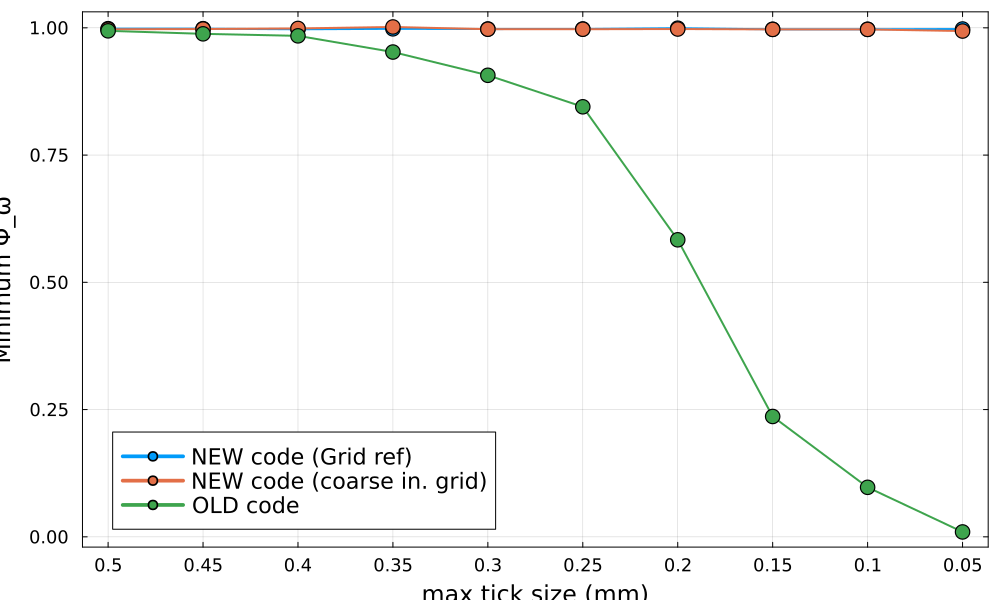

In [7]:
x = 1:length(grid_comp)
labels = string.(grid_comp)

p = plot(
    x, wp_new_grid_ref;
    seriestype = :path,
    marker = :circle,
    markersize = 8,                 # marker più grandi
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    ylabel = "Minimum Φ_ω",
    lw = 2,                         # linea più spessa
    legend = true,
    label = "NEW code (Grid ref)",
    framestyle = :box,
    grid = true,
    gridalpha = 0.1,
    size = (1000, 600),             # figura più grande

    # ---- FONT SIZE ----
    guidefontsize = 16,             # xlabel & ylabel
    tickfontsize = 12,              # numeri assi
    legendfontsize = 15,            # legenda
    titlefontsize = 20              # eventuale titolo
)

plot!(x, wp_new_coarse_initial_grid_opt;
    seriestype = :path,
    marker = :circle,
    markersize = 8,
    lw = 2,
    label = "NEW code (coarse in. grid)"
)

plot!(x, wp_old;
    seriestype = :path,
    marker = :circle,
    markersize = 8,
    lw = 2,
    label = "OLD code"
)


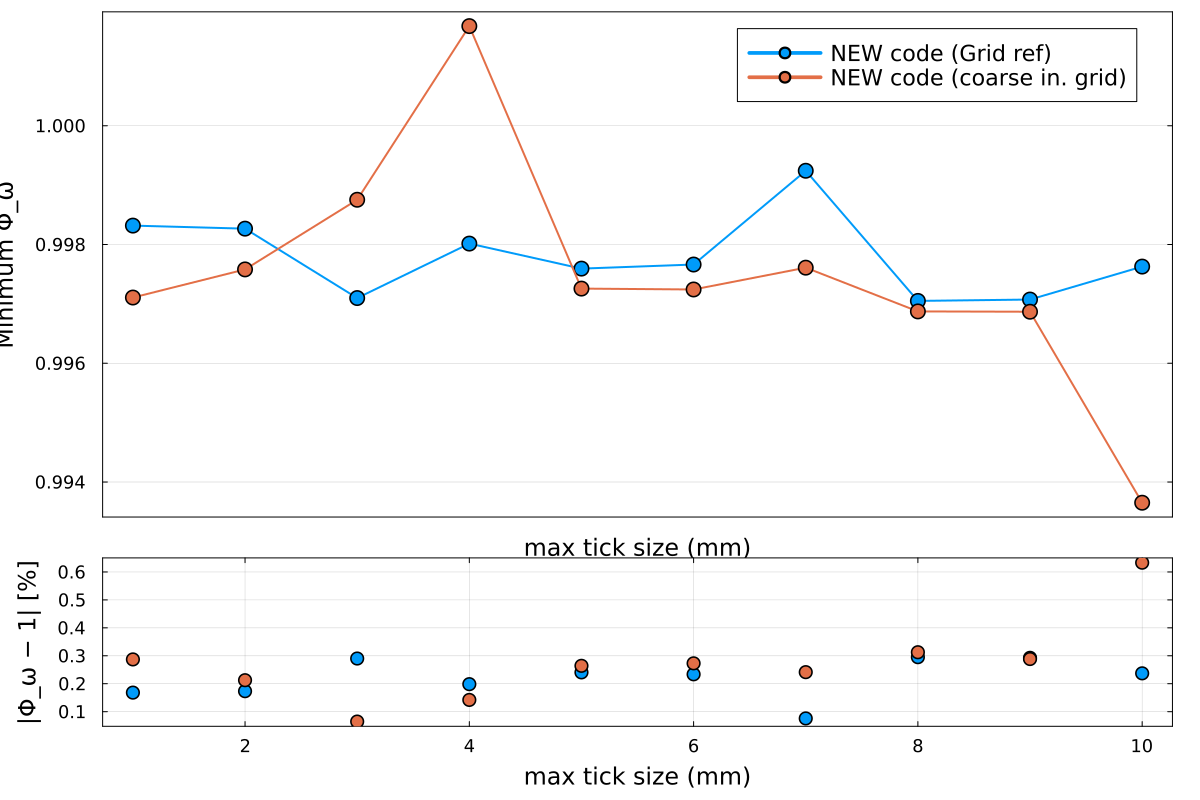

In [12]:
x = 1:length(grid_comp)
labels = string.(grid_comp)

p1 = plot(
    x, wp_new_grid_ref;
    seriestype = :path,
    marker = :circle,
    markersize = 8,                 # marker più grandi
    xlabel = "max tick size (mm)",
    ylabel = "Minimum Φ_ω",
    lw = 2,                         # linea più spessa
    legend = true,
    label = "NEW code (Grid ref)",
    framestyle = :box,
    grid = true,
    gridalpha = 0.1,
    size = (1000, 600),             # figura più grande
    xticks = false,
    # ---- FONT SIZE ----
    guidefontsize = 16,             # xlabel & ylabel
    tickfontsize = 12,              # numeri assi
    legendfontsize = 15,            # legenda
    titlefontsize = 20              # eventuale titolo
)

plot!(x, wp_new_coarse_initial_grid_opt;
    seriestype = :path,
    marker = :circle,
    markersize = 8,
    lw = 2,
    label = "NEW code (coarse in. grid)"
)


p2 = scatter(
    x,
    abs.((wp_new_grid_ref .- 1) .*100),
    ylabel = "|Φ_ω − 1| [%]",
    #xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = true,
    label = "",
    guidefontsize = 16,             # xlabel & ylabel
    tickfontsize = 12,              # numeri assi
    legendfontsize = 15,            # legenda
    titlefontsize = 20  ,
    markersize = 7,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)
 scatter!(
    x,
    abs.((wp_new_coarse_initial_grid .- 1) .*100),
    ylabel = "|Φ_ω − 1| [%]",
    #xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = true,
    label = "",
    guidefontsize = 16,             # xlabel & ylabel
    tickfontsize = 12,              # numeri assi
    legendfontsize = 15,            # legenda
    titlefontsize = 20  ,
    markersize = 7,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

p = plot(
    p1,
    p2,
    layout = Plots.grid(
        2, 1,
        heights = [0.75, 0.25],
        hspace = 0mm
    ),
    link = :x, size = (1200, 800)
)

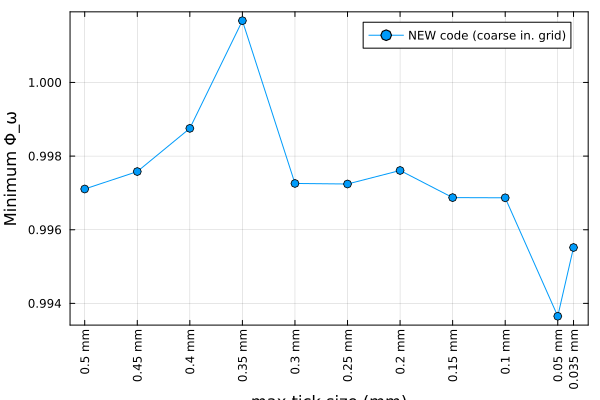

In [19]:
grid = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25 , 0.2, 0.15, 0.1,  0.05, 0.035]
wp = [0.99713,0.99787384 ,0.99935406, 1.0014204, 0.99735886, 0.99727 , 0.99758554, 0.9968726 , 0.9971157, 0.99646914, 0.9936677, 0.9954815]
wp_opt = [ 0.9971068, 0.99758047,  0.9987536, 1.0016781,  0.9972573, 0.9972425, 0.99760973,  0.996873, 0.9968678, 0.99365115, 0.99551797]
plot(grid, wp_opt,
     xlabel = "max tick size (mm)",
    ylabel = "Minimum Φ_ω",
     marker=:o,
    # title="Minimum Weighting Potential vs max_tick_distance",
     xticks=(grid, ["0.5 mm", "0.45 mm", "0.4 mm", "0.35 mm", "0.3 mm", "0.25 mm", "0.2 mm", "0.15 mm", "0.1 mm", "0.05 mm", "0.035 mm"]),
     xrotation=90,
     frame = :box,
      label = "NEW code (coarse in. grid)",
     xflip = true)  # questo inverte l'asse X